# EDA - Data from 2022 to 2025 

Objective of the notebook: Investigate how significant wave height (WVHT) varies with meteorological and oceanographic conditions measured by buoy 41001, and identify variables that may be useful for a regression model.

# loading the data and the libraries:

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [82]:
cols=["YY","MM","DD","hh","mm","WDIR","WSPD","GST","WVHT",
        "DPD","APD","MWD","PRES","ATMP","WTMP","DEWP","VIS","TIDE"]
data2022=pd.read_csv("../data/41001h2022.txt",sep=r'\s+', skiprows=2, names=cols)


# Undrestanding the data

In [83]:
data2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43766 entries, 0 to 43765
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YY      43766 non-null  int64  
 1   MM      43766 non-null  int64  
 2   DD      43766 non-null  int64  
 3   hh      43766 non-null  int64  
 4   mm      43766 non-null  int64  
 5   WDIR    43766 non-null  int64  
 6   WSPD    43766 non-null  float64
 7   GST     43766 non-null  float64
 8   WVHT    43766 non-null  float64
 9   DPD     43766 non-null  float64
 10  APD     43766 non-null  float64
 11  MWD     43766 non-null  int64  
 12  PRES    43766 non-null  float64
 13  ATMP    43766 non-null  float64
 14  WTMP    43766 non-null  float64
 15  DEWP    43766 non-null  float64
 16  VIS     43766 non-null  float64
 17  TIDE    43766 non-null  float64
dtypes: float64(11), int64(7)
memory usage: 6.0 MB


In [84]:
data2022.columns

Index(['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
       'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'],
      dtype='object')

In [85]:
data2022.shape

(43766, 18)

In [86]:
data2022.isna().sum()

YY      0
MM      0
DD      0
hh      0
mm      0
WDIR    0
WSPD    0
GST     0
WVHT    0
DPD     0
APD     0
MWD     0
PRES    0
ATMP    0
WTMP    0
DEWP    0
VIS     0
TIDE    0
dtype: int64

# Cleaning

In [87]:
data2022v2=data2022.copy()
data2022v2=data2022.drop(["WDIR","MWD","ATMP","WTMP","DEWP","VIS","TIDE"], axis=1)

In [88]:

data2022v2.rename(columns=
    {
    "YY":"Y",
    "MM":"M",
    "DD":"D",
    "hh":"h",
    "mm":"m",
    "WSPD":"Wind speed",
    "GST":"Wind gust",
    "WVHT":"Significant wave height",
    "DPD":"Dominant wave period",
    "APD":"Avg wave period",
    "PRES":"Atmospheric pressure",
    }
    ,inplace=True)

In [89]:
data2022v2.columns

Index(['Y', 'M', 'D', 'h', 'm', 'Wind speed', 'Wind gust',
       'Significant wave height', 'Dominant wave period', 'Avg wave period',
       'Atmospheric pressure'],
      dtype='object')

In [90]:
col = ["Significant wave height", "Dominant wave period", "Avg wave period"]
data2022v2 = data2022v2[(data2022v2[col] != 99.00).all(axis=1)]

In [91]:
data2022v2.head()

,Y,M,D,h,m,Wind speed,Wind gust,Significant wave height,Dominant wave period,Avg wave period,Atmospheric pressure
1,2022,3,2,20,40,8.3,10.8,1.31,7.69,5.45,1017.5
7,2022,3,2,21,40,9.3,11.5,1.46,5.56,5.40,1017.7
13,2022,3,2,22,40,7.7,9.6,1.63,5.88,5.50,1018.0
19,2022,3,2,23,40,7.3,10.7,1.40,5.88,5.49,1018.3
25,2022,3,3,0,40,4.9,6.5,1.32,5.26,5.45,1018.7


In [96]:
data2022v2['time'] = pd.to_datetime(
    data2022v2[['Y','M','D','h','m']].rename(
        columns={'Y':'year','M':'month','D':'day','h':'hour','m':'minute'}
    )
)

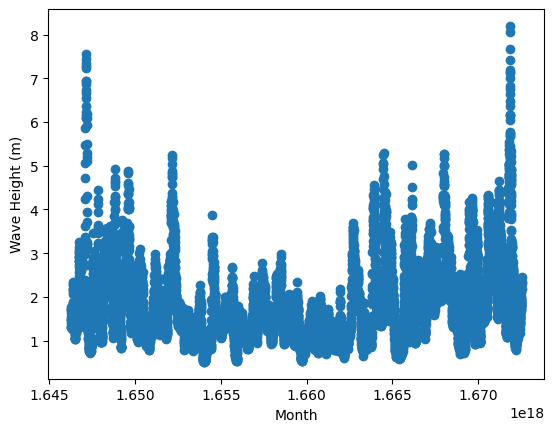

In [98]:
x = pd.to_numeric(data2022v2["time"], errors="coerce")
y = pd.to_numeric(data2022v2["Significant wave height"], errors="coerce")

plt.scatter(x, y)
plt.xlabel("Month")
plt.ylabel("Wave Height (m)")
plt.show()